Basic Data Processing...

In [2]:
import pandas as pd
sheets = pd.read_excel("./data/Scats Data October 2006.xls", sheet_name=None)

removed_days = sheets["Notes"]["Unnamed: 1"].dropna().to_list()[5:]
removed_days = [int(i) for i in removed_days]
# removed_days

df_info = sheets["Summary Of Data"].loc[2:]
df_info.columns = df_info.iloc[0]
df_info = df_info[1:]
df_info["SCATS Number"] = df_info["SCATS Number"].ffill()

df_info.dropna(axis=1, inplace=True)
df_info = df_info.convert_dtypes().infer_objects()

df_info_filtered = df_info[df_info["Total"].between(7, 31)]
# df_info_filtered

df_info

2,SCATS Number,Location,Total
3,0970,HIGH STREET_RD E of WARRIGAL_RD,31
4,0970,HIGH STREET_RD W of WARRIGAL_RD,30
5,0970,WARRIGAL_RD N of HIGH STREET_RD,31
6,0970,WARRIGAL_RD S of HIGH STREET_RD,31
7,2000,BURWOOD_HWY E of WARRIGAL_RD,29
...,...,...,...
137,4812,SWAN_ST SW of MADDEN_GV,26
138,4821,BURNLEY_ST S OF VICTORIA_ST,31
139,4821,VICTORIA_ST E OF BURNLEY_ST,31
140,4821,VICTORIA_ST W OF BURNLEY_ST,31


We create an identifier for each location: SCATS Number + HF Vicroads Internal

In [3]:

# imagine having good formatting
df = sheets["Data"]
df.columns = pd.Series(df.loc[0])
df = df.loc[1:]

# remove added time
df.loc[:, 'Date'] = pd.to_datetime(df['Date']).dt.date
df = df.convert_dtypes()

# filter good locations
df = df.loc[df["Location"].isin(df_info_filtered["Location"])]

# add location identifier: SCARS Number + VicRoads Internal
df.loc[:, "Identifier"] = df["SCATS Number"].astype(str) + " - " + df["HF VicRoads Internal"].astype(str)
df.columns = df.columns.str.strip()


df


,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V87,V88,V89,V90,V91,V92,V93,V94,V95,Identifier
1,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01,...,97,97,66,81,50,59,47,29,34,0970 - 249
2,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02,...,102,107,114,80,60,62,48,44,26,0970 - 249
3,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03,...,132,114,86,93,90,73,57,29,40,0970 - 249
4,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-04,...,113,132,101,113,90,78,66,52,44,0970 - 249
5,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-05,...,120,116,113,99,91,61,55,49,36,0970 - 249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4188,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-27,...,121,127,103,122,124,117,99,108,88,4821 - 6673
4189,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-28,...,93,93,105,105,112,82,97,106,107,4821 - 6673
4190,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-29,...,118,83,76,66,64,77,60,49,45,4821 - 6673
4191,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-30,...,88,89,80,74,48,67,62,50,62,4821 - 6673


In [4]:
df

,SCATS Number,Location,CD_MELWAY,NB_LATITUDE,NB_LONGITUDE,HF VicRoads Internal,VR Internal Stat,VR Internal Loc,NB_TYPE_SURVEY,Date,...,V87,V88,V89,V90,V91,V92,V93,V94,V95,Identifier
1,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-01,...,97,97,66,81,50,59,47,29,34,0970 - 249
2,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-02,...,102,107,114,80,60,62,48,44,26,0970 - 249
3,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-03,...,132,114,86,93,90,73,57,29,40,0970 - 249
4,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-04,...,113,132,101,113,90,78,66,52,44,0970 - 249
5,0970,WARRIGAL_RD N of HIGH STREET_RD,060 G10,-37.86703,145.09159,249,182,1,1,2006-10-05,...,120,116,113,99,91,61,55,49,36,0970 - 249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4188,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-27,...,121,127,103,122,124,117,99,108,88,4821 - 6673
4189,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-28,...,93,93,105,105,112,82,97,106,107,4821 - 6673
4190,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-29,...,118,83,76,66,64,77,60,49,45,4821 - 6673
4191,4821,VICTORIA_ST W OF BURNLEY_ST,002HF02,-37.81296,145.0083,6673,1513,7,1,2006-10-30,...,88,89,80,74,48,67,62,50,62,4821 - 6673


In [5]:
df.to_csv("./data/Scats Data.csv")

Format: Identifier + columns as timestamps

In [6]:
times_dict = {}
vcols = [f"V{str(i).zfill(2)}" for i in range(96)]
numbered_colnames = list(range(96 * 31))
for col in vcols:
    i = int(col[1:]) if len(col[1:]) > 0 else 0
    t = i * 15 
    h = t // 60 
    m = t % 60
    times_dict[col] = f"{str(h).zfill(2)}:{str(m).zfill(2)}" 
times_dict

{'V00': '00:00',
 'V01': '00:15',
 'V02': '00:30',
 'V03': '00:45',
 'V04': '01:00',
 'V05': '01:15',
 'V06': '01:30',
 'V07': '01:45',
 'V08': '02:00',
 'V09': '02:15',
 'V10': '02:30',
 'V11': '02:45',
 'V12': '03:00',
 'V13': '03:15',
 'V14': '03:30',
 'V15': '03:45',
 'V16': '04:00',
 'V17': '04:15',
 'V18': '04:30',
 'V19': '04:45',
 'V20': '05:00',
 'V21': '05:15',
 'V22': '05:30',
 'V23': '05:45',
 'V24': '06:00',
 'V25': '06:15',
 'V26': '06:30',
 'V27': '06:45',
 'V28': '07:00',
 'V29': '07:15',
 'V30': '07:30',
 'V31': '07:45',
 'V32': '08:00',
 'V33': '08:15',
 'V34': '08:30',
 'V35': '08:45',
 'V36': '09:00',
 'V37': '09:15',
 'V38': '09:30',
 'V39': '09:45',
 'V40': '10:00',
 'V41': '10:15',
 'V42': '10:30',
 'V43': '10:45',
 'V44': '11:00',
 'V45': '11:15',
 'V46': '11:30',
 'V47': '11:45',
 'V48': '12:00',
 'V49': '12:15',
 'V50': '12:30',
 'V51': '12:45',
 'V52': '13:00',
 'V53': '13:15',
 'V54': '13:30',
 'V55': '13:45',
 'V56': '14:00',
 'V57': '14:15',
 'V58': '14:30

In [7]:
import numpy as np
groups = df.groupby(by="Identifier")
df_processed = pd.DataFrame()

# add latitude and longtitude
lat_dict = {}
long_dict = {}
identifiers = []
locations_dict = {}

for id, group in groups:
    # all latitude and longtitude is the same
    lat_dict[id] = group["NB_LATITUDE"].iloc[0]
    long_dict[id] = group["NB_LONGITUDE"].iloc[0]
    locations_dict[id] = group["Location"].iloc[0].upper()
    
    combined = pd.concat([group[c] for c in vcols], ignore_index=True)
    df_processed[id] = combined
    
    # index
    identifiers.append(id)
    

    
# df_processed.fillna(-1, inplace=True)
df_processed = pd.concat([
    df_processed, pd.DataFrame([lat_dict]), pd.DataFrame([long_dict]), pd.DataFrame([locations_dict])
])

# post processing: row = identifier + lat-long for coordinate + flow

df_processed = df_processed.T.copy()
df_processed.columns = [*df_processed.columns[:-3], "lat", "long", "location"]
df_processed["id"] = [str(i).strip() for i in identifiers]
df_processed = df_processed[df_processed["lat"] != 0]

valid_lengths = df_processed[numbered_colnames].notna().sum(axis=1)
min_valid_len = valid_lengths.min()
print("Shortest complete length:", min_valid_len)

df_trimmed = df_processed.drop(labels=[i for i in numbered_colnames if i > min_valid_len], axis=1)
df_trimmed





Shortest complete length: 2112


,0,1,2,3,4,5,6,7,8,9,...,2107,2108,2109,2110,2111,2112,lat,long,location,id
0970 - 10503,92,31,20,32,42,31,87,108,32,29,...,423,361,365,414,380,422,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503
0970 - 16116,37,10,8,6,10,9,27,40,9,8,...,138,124,173,176,170,148,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116
0970 - 249,86,32,26,32,40,36,62,116,23,27,...,354,265,277,358,308,348,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249
0970 - 5887,47,15,10,20,16,42,67,23,16,22,...,351,349,383,318,352,214,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887
2000 - 10505,110,28,23,30,40,38,72,116,32,35,...,211,252,283,290,287,202,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4812 - 6302,49,16,15,22,14,28,38,47,11,8,...,44,56,46,60,73,67,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302
4821 - -1,0,1,0,3,2,2,0,0,0,0,...,11,9,12,17,5,9,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1
4821 - 14527,25,10,7,12,14,11,38,27,9,11,...,153,94,186,162,180,180,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527
4821 - 16911,44,14,14,25,23,20,46,55,13,21,...,167,187,152,180,195,212,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911


check missing data here

In [8]:
import numpy as np
import pandas as pd

missing_per_sensor = df_processed[numbered_colnames].isna().sum(axis=1)
missing_per_time = df_processed[numbered_colnames].isna().sum(axis=0)

print("Missing per sensor (rows):", missing_per_sensor.describe())
print("Missing per time step (columns):", missing_per_time.describe())


Missing per sensor (rows): count    136.000000
mean      84.000000
std      181.560642
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      864.000000
dtype: float64
Missing per time step (columns): count    2976.000000
mean        3.838710
std         8.448969
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        33.000000
dtype: float64


In [9]:
from matplotlib import pyplot as plt 

def count_trailing_nans(row):
    """Count consecutive NaNs from the end of a row (right side)."""
    # Convert to boolean array: True where NaN
    is_na = row.isna().to_numpy()
    
    # Reverse it, count consecutive True from start
    count = 0
    for val in is_na[::-1]:
        if val:
            count += 1
        else:
            break
    return count

a = df_processed[numbered_colnames].apply(count_trailing_nans, axis=1)
print(f"Max: {a.max()}")
print(f"Min: {a.min()}")


Max: 864
Min: 0


In [10]:
df_processed.columns

Index([         0,          1,          2,          3,          4,          5,
                6,          7,          8,          9,
       ...
             2970,       2971,       2972,       2973,       2974,       2975,
            'lat',     'long', 'location',       'id'],
      dtype='object', length=2980)

In [11]:
import numpy as np

def count_trailing_nans(row):
    return np.argmax(~np.isnan(row[::-1])) if np.isnan(row).any() else 0

trailing_nans = df_processed[numbered_colnames].copy(deep=True).fillna(np.nan)

trailing_nans


/tmp/ipykernel_8880/3176870093.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  trailing_nans = df_processed[numbered_colnames].copy(deep=True).fillna(np.nan)


,0,1,2,3,4,5,6,7,8,9,...,2966,2967,2968,2969,2970,2971,2972,2973,2974,2975
0970 - 10503,92,31,20,32,42,31,87,108,32,29,...,39.0,33.0,38.0,58.0,55.0,86.0,119.0,45.0,37.0,66.0
0970 - 16116,37,10,8,6,10,9,27,40,9,8,...,7.0,11.0,11.0,11.0,22.0,32.0,33.0,12.0,15.0,14.0
0970 - 249,86,32,26,32,40,36,62,116,23,27,...,28.0,37.0,36.0,32.0,48.0,80.0,98.0,48.0,27.0,33.0
0970 - 5887,47,15,10,20,16,42,67,23,16,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000 - 10505,110,28,23,30,40,38,72,116,32,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4812 - 6302,49,16,15,22,14,28,38,47,11,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4821 - -1,0,1,0,3,2,2,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4821 - 14527,25,10,7,12,14,11,38,27,9,11,...,14.0,13.0,32.0,15.0,27.0,42.0,43.0,9.0,12.0,14.0
4821 - 16911,44,14,14,25,23,20,46,55,13,21,...,29.0,19.0,45.0,38.0,36.0,65.0,82.0,28.0,28.0,28.0


In [12]:
from matplotlib import pyplot as plt 
import numpy as np

numbered_colnames = [i for i in range(2976)]

def plot_identifier_flow(identifier: str):
    identifier = identifier.strip()
    row = df_processed[df_processed["id"] == identifier]
    data = row[numbered_colnames].to_numpy().flatten()
    print(data)
    
    
    plt.figure(figsize=(12, 4))
    
    plt.title(f"Observed data over sensor with identifier {identifier}")
    plt.xlabel("i'th 15-minute interval")
    plt.ylabel("Number of vehicles")
    plt.plot(np.arange(len(data)), data, "o", label=identifier)
    plt.legend()


# plot_identifier_flow("2000 - 10505")

We visualize the location using specific columns from our database

In [13]:
import numpy as np

df_locations = df_processed[["lat", "long", "location", "id"]].copy()

df_locations[["position", "road"]] = df_locations["location"].str.split(" OF ", n=1, expand=True)
df_locations["position"] = df_locations["position"].str.strip()
df_locations["road"] = df_locations["road"].str.strip()

df_locations = df_locations[df_locations["lat"] != 0]
df_locations.infer_objects()
df_locations

,lat,long,location,id,position,road
0970 - 10503,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503,WARRIGAL_RD S,HIGH STREET_RD
0970 - 16116,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116,HIGH STREET_RD E,WARRIGAL_RD
0970 - 249,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249,WARRIGAL_RD N,HIGH STREET_RD
0970 - 5887,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887,HIGH STREET_RD W,WARRIGAL_RD
2000 - 10505,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505,WARRIGAL_RD S,BURWOOD_HWY
...,...,...,...,...,...,...
4812 - 6302,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302,SWAN_ST NE,MADDEN_GV
4821 - -1,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1,WALMER_ST N,VICTORIA_ST
4821 - 14527,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527,BURNLEY_ST S,VICTORIA_ST
4821 - 16911,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911,VICTORIA_ST E,BURNLEY_ST


which allows us to draw this nice looking diagram

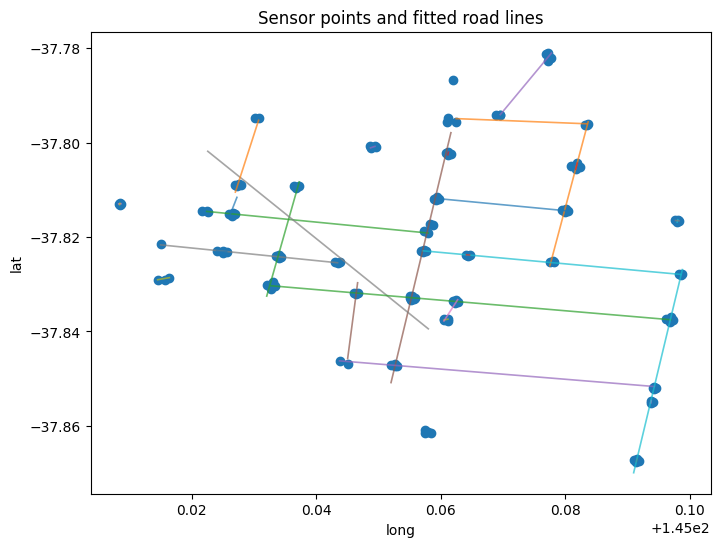

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

plt.figure(figsize=(8, 6))

# scatter all points first
plt.scatter(df_locations["long"], df_locations["lat"])

for road, group in df_locations.groupby("road"):
    # drop any missing or zero coordinates
    g = group[(group["lat"] != 0) & (group["long"] != 0)]
    if len(g) < 2:
        continue

    # fit line latitude = a * longitude + b
    X = np.array(g["long"].values).reshape(-1, 1)
    y = np.array(g["lat"].values)
    model = LinearRegression().fit(X, y)
    x_line = np.linspace(X.min(), X.max(), 50)
    y_line = model.predict(x_line.reshape(-1, 1))

    # draw road line
    plt.figure
    plt.plot(x_line, y_line, lw=1.2, alpha=0.7, label=road)

plt.xlabel("long")
plt.ylabel("lat")
plt.title("Sensor points and fitted road lines")
# plt.legend()
plt.show()


Further location analysis...

for splitting

In [15]:
df_locations["position"] = df_locations["position"].astype(str).apply(lambda x: x.replace("HIGH STREET", "HIGH_STREET"))

df_locations

,lat,long,location,id,position,road
0970 - 10503,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503,WARRIGAL_RD S,HIGH STREET_RD
0970 - 16116,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116,HIGH_STREET_RD E,WARRIGAL_RD
0970 - 249,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249,WARRIGAL_RD N,HIGH STREET_RD
0970 - 5887,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887,HIGH_STREET_RD W,WARRIGAL_RD
2000 - 10505,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505,WARRIGAL_RD S,BURWOOD_HWY
...,...,...,...,...,...,...
4812 - 6302,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302,SWAN_ST NE,MADDEN_GV
4821 - -1,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1,WALMER_ST N,VICTORIA_ST
4821 - 14527,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527,BURNLEY_ST S,VICTORIA_ST
4821 - 16911,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911,VICTORIA_ST E,BURNLEY_ST


In [16]:
# df_locations["position"] = df_locations["position"].astype(str).apply(lambda x: x.replace("HIGH STREET", "HIGH_STREET"))
# df_locations["position"] = df_locations["position"].astype(str).apply(lambda x: x.replace("MONT ALBERT", "MONT_ALBERT"))

df_locations

,lat,long,location,id,position,road
0970 - 10503,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503,WARRIGAL_RD S,HIGH STREET_RD
0970 - 16116,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116,HIGH_STREET_RD E,WARRIGAL_RD
0970 - 249,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249,WARRIGAL_RD N,HIGH STREET_RD
0970 - 5887,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887,HIGH_STREET_RD W,WARRIGAL_RD
2000 - 10505,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505,WARRIGAL_RD S,BURWOOD_HWY
...,...,...,...,...,...,...
4812 - 6302,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302,SWAN_ST NE,MADDEN_GV
4821 - -1,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1,WALMER_ST N,VICTORIA_ST
4821 - 14527,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527,BURNLEY_ST S,VICTORIA_ST
4821 - 16911,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911,VICTORIA_ST E,BURNLEY_ST


In [17]:
a = df_locations["position"].str.split(" ").apply(lambda x: x[:-1][0]).to_list()
len(a)

136

In [18]:
df_locations["to"], df_locations["direction"] = a = df_locations["position"].str.split(" ").apply(lambda x: x[:-1][0]).to_list(), df_locations["position"].str.split(" ").apply(lambda x: x[-1][0]).to_list()
df_locations["to"] = df_locations["to"].astype(str).replace(" ", "_")
df_locations

,lat,long,location,id,position,road,to,direction
0970 - 10503,-37.8676,145.09146,WARRIGAL_RD S OF HIGH STREET_RD,0970 - 10503,WARRIGAL_RD S,HIGH STREET_RD,WARRIGAL_RD,S
0970 - 16116,-37.86735,145.09195,HIGH STREET_RD E OF WARRIGAL_RD,0970 - 16116,HIGH_STREET_RD E,WARRIGAL_RD,HIGH_STREET_RD,E
0970 - 249,-37.86703,145.09159,WARRIGAL_RD N OF HIGH STREET_RD,0970 - 249,WARRIGAL_RD N,HIGH STREET_RD,WARRIGAL_RD,N
0970 - 5887,-37.86723,145.09103,HIGH STREET_RD W OF WARRIGAL_RD,0970 - 5887,HIGH_STREET_RD W,WARRIGAL_RD,HIGH_STREET_RD,W
2000 - 10505,-37.85221,145.09425,WARRIGAL_RD S OF BURWOOD_HWY,2000 - 10505,WARRIGAL_RD S,BURWOOD_HWY,WARRIGAL_RD,S
...,...,...,...,...,...,...,...,...
4812 - 6302,-37.82859,145.01644,SWAN_ST NE OF MADDEN_GV,4812 - 6302,SWAN_ST NE,MADDEN_GV,SWAN_ST,N
4821 - -1,-37.81285,145.00849,WALMER_ST N OF VICTORIA_ST,4821 - -1,WALMER_ST N,VICTORIA_ST,WALMER_ST,N
4821 - 14527,-37.81312,145.00844,BURNLEY_ST S OF VICTORIA_ST,4821 - 14527,BURNLEY_ST S,VICTORIA_ST,BURNLEY_ST,S
4821 - 16911,-37.81293,145.00865,VICTORIA_ST E OF BURNLEY_ST,4821 - 16911,VICTORIA_ST E,BURNLEY_ST,VICTORIA_ST,E


Now for actual functionality. 

My teacher said that she wants an "adjacency graph". However, for the life of me, I can't find anything like that. However, we can determine something *approximately* approximately like that via our friend k-Nearest Neighbors!

In [19]:
from sklearn.metrics import pairwise_distances

coordinates = df_locations[["lat", "long"]].to_numpy().astype(np.float64)
print(pairwise_distances(coordinates, metric="haversine"))


[[0.         0.00054393 0.00058423 ... 0.09859992 0.09853288 0.09880458]
 [0.00054393 0.         0.00047788 ... 0.09886853 0.09880017 0.09907292]
 [0.00058423 0.00047788 0.         ... 0.09839673 0.09832816 0.09860108]
 ...
 [0.09859992 0.09886853 0.09839673 ... 0.         0.00028219 0.00021201]
 [0.09853288 0.09880017 0.09832816 ... 0.00028219 0.         0.00034903]
 [0.09880458 0.09907292 0.09860108 ... 0.00021201 0.00034903 0.        ]]


k-Nearest Neighbots

In [20]:
import numpy as np
from sklearn.metrics import pairwise_distances

# assuming df_locations is your DataFrame with NB_LATITUDE & NB_LONGITUDE and same order as the columns of your wide matrix
coords = df_locations[['lat','long']].to_numpy(dtype=float)

dist_rad = pairwise_distances(coords, metric='haversine')
earth_km = 6371.0
dist_km = dist_rad * earth_km

N = dist_km.shape[0]


k = 5
A = np.zeros((N,N))

for i in range(N):
    # exclude self
    neigh_idx = np.argsort(dist_km[i])[1:k+1]
    for j in neigh_idx:
        A[i, j] = 1
        A[j, i] = 1  # symmetric

# optional weighting
sigma = np.mean(dist_km[dist_km>0])
W = np.exp(-(dist_km**2)/(2*sigma**2))
A_weighted = W * (A>0)

# normalize each row
row_sum = A_weighted.sum(axis=1, keepdims=True)
A_norm = np.array(A_weighted / (row_sum + 1e-9))

# # whatever matrix you choose (A, A_weighted, A_norm) becomes your adjacency
# np.save("adjacency_matrix.npy", A_norm)

# # also save mapping from index -> Identifier
# np.save("node_identifiers.npy", df_locations['id'].to_numpy())


Big moment. Now we will convert the data into its simplest form: Just identifiers + flow data

In [21]:
df_series = df_processed[numbered_colnames]

t = 10 ** 9

# check
for i in range(len(numbered_colnames)):
    if df_series[i].hasnans:
        df_series = df_series.drop(labels=[i], axis=1)
        
df_series = df_series.astype(np.float32)
df_series

,0,1,2,3,4,5,6,7,8,9,...,2102,2103,2104,2105,2106,2107,2108,2109,2110,2111
0970 - 10503,92.0,31.0,20.0,32.0,42.0,31.0,87.0,108.0,32.0,29.0,...,323.0,386.0,359.0,370.0,347.0,423.0,361.0,365.0,414.0,380.0
0970 - 16116,37.0,10.0,8.0,6.0,10.0,9.0,27.0,40.0,9.0,8.0,...,168.0,143.0,170.0,167.0,172.0,138.0,124.0,173.0,176.0,170.0
0970 - 249,86.0,32.0,26.0,32.0,40.0,36.0,62.0,116.0,23.0,27.0,...,328.0,352.0,271.0,266.0,302.0,354.0,265.0,277.0,358.0,308.0
0970 - 5887,47.0,15.0,10.0,20.0,16.0,42.0,67.0,23.0,16.0,22.0,...,365.0,367.0,363.0,186.0,107.0,351.0,349.0,383.0,318.0,352.0
2000 - 10505,110.0,28.0,23.0,30.0,40.0,38.0,72.0,116.0,32.0,35.0,...,296.0,277.0,324.0,321.0,260.0,211.0,252.0,283.0,290.0,287.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4812 - 6302,49.0,16.0,15.0,22.0,14.0,28.0,38.0,47.0,11.0,8.0,...,47.0,44.0,49.0,74.0,43.0,44.0,56.0,46.0,60.0,73.0
4821 - -1,0.0,1.0,0.0,3.0,2.0,2.0,0.0,0.0,0.0,0.0,...,4.0,8.0,1.0,2.0,8.0,11.0,9.0,12.0,17.0,5.0
4821 - 14527,25.0,10.0,7.0,12.0,14.0,11.0,38.0,27.0,9.0,11.0,...,148.0,152.0,115.0,106.0,148.0,153.0,94.0,186.0,162.0,180.0
4821 - 16911,44.0,14.0,14.0,25.0,23.0,20.0,46.0,55.0,13.0,21.0,...,200.0,188.0,239.0,224.0,175.0,167.0,187.0,152.0,180.0,195.0


In [22]:
arr = df_series.to_numpy().astype(np.float32)
data = arr.copy()
data

array([[ 92.,  31.,  20., ..., 365., 414., 380.],
       [ 37.,  10.,   8., ..., 173., 176., 170.],
       [ 86.,  32.,  26., ..., 277., 358., 308.],
       ...,
       [ 25.,  10.,   7., ..., 186., 162., 180.],
       [ 44.,  14.,  14., ..., 152., 180., 195.],
       [ 86.,  34.,  30., ..., 259., 266., 310.]],
      shape=(136, 2112), dtype=float32)

Training parameters

In [23]:
# ====================================
# STEP 1: LOAD & PREPARE DATA
# ====================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Constants
NUM_SENSORS = data.shape[0]  # 136 sensors
NUM_TIMESTEPS = data.shape[1]  # 2112 timesteps (22 days × 96 intervals/day)
LOOKBACK_HOURS = 3 # Lookback how many hours
LOOKBACK = LOOKBACK_HOURS * 4  # Use past LOOKBACK_HOURS hours (12 × 15min intervals)
HORIZON = 4    # Predict next 1 hour (4 × 15min intervals)

print(f"Dataset: {NUM_SENSORS} sensors, {NUM_TIMESTEPS} timesteps")
print(f"Lookback: {LOOKBACK} steps (3 hours)")
print(f"Horizon: {HORIZON} steps (1 hour)")

# Create spatial features: average traffic at nearby sensors
neighbor_avg = A_norm.dot(data)  # Matrix multiply: adjacency × traffic data

2025-11-12 20:15:41.933202: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 20:15:42.634642: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-12 20:15:44.257260: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Dataset: 136 sensors, 2112 timesteps
Lookback: 12 steps (3 hours)
Horizon: 4 steps (1 hour)


In [24]:
# ====================================
# STEP 2: CREATE SLIDING WINDOWS
# ====================================
def create_windows(traffic_data: np.ndarray, neighbor_data: np.ndarray, lookback: int, horizon: int):
    """
    Create sliding windows for training.
    
    For each time point, we create:
    - Input: [past traffic, past neighbor traffic] for lookback timesteps
    - Output: future traffic for horizon timesteps
    
    Returns:
        X: shape (num_windows, lookback, 2*NUM_SENSORS)
        Y: shape (num_windows, horizon, NUM_SENSORS)
    """
    X_list = []
    Y_list = []
    
    max_time = traffic_data.shape[1] - lookback - horizon + 1
    
    for t in range(max_time):
        # Get past data
        past_traffic = traffic_data[:, t : t + lookback]  # (136, 12)
        past_neighbors = neighbor_data[:, t : t + lookback]  # (136, 12)
        
        # Stack features: [traffic, neighbors] → (272, 12) → transpose → (12, 272)
        features = np.vstack([past_traffic, past_neighbors]).T
        X_list.append(features)
        
        # Get future data to predict
        future_traffic = traffic_data[:, t + lookback : t + lookback + horizon]  # (136, 4)
        Y_list.append(future_traffic.T)  # Transpose to (4, 136)
    
    return np.array(X_list), np.array(Y_list)


X, Y = create_windows(data, neighbor_avg, LOOKBACK, HORIZON)
print(f"\nCreated {len(X)} training windows")
print(f"Input shape:  {X.shape} → (windows, lookback_steps, features)")
print(f"Output shape: {Y.shape} → (windows, horizon_steps, sensors)")


Created 2097 training windows
Input shape:  (2097, 12, 272) → (windows, lookback_steps, features)
Output shape: (2097, 4, 136) → (windows, horizon_steps, sensors)


In [25]:
# ====================================
# STEP 3: SPLIT DATA (TEMPORAL ORDER)
# ====================================
# Important: Split by TIME, not randomly!
# This simulates real-world scenario: train on past, test on future

total_windows = len(X)
train_split = int(0.70 * total_windows)  # 70% for training
val_split = int(0.85 * total_windows)    # 15% for validation, 15% for test

X_train, Y_train = X[:train_split], Y[:train_split]
X_val, Y_val = X[train_split:val_split], Y[train_split:val_split]
X_test, Y_test = X[val_split:], Y[val_split:]

print(f"\nData split:")
print(f"  Train: {len(X_train)} windows (70%)")
print(f"  Val:   {len(X_val)} windows (15%)")
print(f"  Test:  {len(X_test)} windows (15%)")


Data split:
  Train: 1467 windows (70%)
  Val:   315 windows (15%)
  Test:  315 windows (15%)


In [26]:
def normalize_dataset(X_train: np.ndarray, Y_train: np.ndarray, X_val: np.ndarray, Y_val: np.ndarray, X_test: np.ndarray, Y_test: np.ndarray, num_sensors: int):
    """Normalize inputs and outputs using StandardScaler."""
    
    # Flatten for fitting scaler
    X_train_flat = X_train.reshape(-1, 2 * num_sensors)
    Y_train_flat = Y_train.reshape(-1, num_sensors)
    
    # Fit scalers on training data only
    scaler_X = StandardScaler().fit(X_train_flat)
    scaler_Y = StandardScaler().fit(Y_train_flat)
    
    # Transform all datasets
    X_train_norm = scaler_X.transform(X_train_flat).reshape(X_train.shape)
    X_val_norm = scaler_X.transform(X_val.reshape(-1, 2 * num_sensors)).reshape(X_val.shape)
    X_test_norm = scaler_X.transform(X_test.reshape(-1, 2 * num_sensors)).reshape(X_test.shape)
    
    Y_train_norm = scaler_Y.transform(Y_train_flat).reshape(Y_train.shape)
    Y_val_norm = scaler_Y.transform(Y_val.reshape(-1, num_sensors)).reshape(Y_val.shape)
    Y_test_norm = scaler_Y.transform(Y_test.reshape(-1, num_sensors)).reshape(Y_test.shape)
    
    return (X_train_norm, X_val_norm, X_test_norm,
            Y_train_norm, Y_val_norm, Y_test_norm,
            scaler_X, scaler_Y)
    
X_train_scaled, X_val_scaled, X_test_scaled, \
Y_train_scaled, Y_val_scaled, Y_test_scaled, \
scaler_X, scaler_Y = normalize_dataset(X_train, Y_train, X_val, Y_val, X_test, Y_test, NUM_SENSORS)

In [27]:
# ====================================
# STEP 5: BUILD LSTM MODEL
# ====================================
def build_model(lookback: int, num_sensors: int, horizon: int):
    """
    Build spatial-temporal LSTM model.
    
    Architecture:
      Input → LSTM(128) → Dropout(0.2) → Dense → Output
    """
    model = Sequential([
        Input(shape=(lookback, 2 * num_sensors)),
        LSTM(128, activation='tanh'),
        Dropout(0.2),
        Dense(horizon * num_sensors)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model


model = build_model(LOOKBACK, NUM_SENSORS, HORIZON)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │       205,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 544)            │        70,176 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275,488 (1.05 MB)

 Trainable params: 275,488 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# ====================================
# STEP 6: TRAIN MODEL
# ====================================
# Reshape Y for training (model expects flat output)
Y_train_flat = Y_train_scaled.reshape(len(Y_train_scaled), -1)
Y_val_flat = Y_val_scaled.reshape(len(Y_val_scaled), -1)

# Early stopping: stop if validation loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("\n🚀 Training model...")
history = model.fit(
    X_train_scaled, Y_train_flat,
    validation_data=(X_val_scaled, Y_val_flat),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("✅ Training complete!")


🚀 Training model...
Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.4194 - val_loss: 0.3170
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2457 - val_loss: 0.2411
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2217 - val_loss: 0.1975
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2097 - val_loss: 0.2202
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2023 - val_loss: 0.1931
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1967 - val_loss: 0.1914
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1923 - val_loss: 0.1626
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1898 - val_loss: 0.1636
Epoch 9/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.1841 - val_loss: 0.2307
Epoch 10/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1761 - val_loss: 0.1562
Epoch 11/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1699 - val_loss: 0.1623
Epoch 12/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [29]:
# ====================================
# STEP 7: MAKE PREDICTIONS
# ====================================
print("\n🔮 Generating predictions on test set...")

# Predict (normalized)
Y_pred_scaled = model.predict(X_test_scaled)
Y_pred_scaled = Y_pred_scaled.reshape(-1, HORIZON, NUM_SENSORS)

# Denormalize back to original scale
Y_pred = scaler_Y.inverse_transform(Y_pred_scaled.reshape(-1, NUM_SENSORS)).reshape(Y_pred_scaled.shape)
Y_true = scaler_Y.inverse_transform(Y_test_scaled.reshape(-1, NUM_SENSORS)).reshape(Y_test_scaled.shape)

print("✓ Predictions generated")


🔮 Generating predictions on test set...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
✓ Predictions generated


In [32]:
# ====================================
# STEP 8: EVALUATE MODEL
# ====================================
def evaluate_model(y_true, y_pred):
    """Calculate MAE and RMSE."""
    mae = mean_absolute_error(y_true.reshape(-1), y_pred.reshape(-1))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse


mae, rmse = evaluate_model(Y_true, Y_pred)

print(f"\n{'='*50}")
print(f"📊 EVALUATION RESULTS")
print(f"{'='*50}")
print(f"MAE:  {mae:.2f} vehicles")
print(f"RMSE: {rmse:.2f} vehicles")
print(f"{'='*50}\n")



📊 EVALUATION RESULTS
MAE:  37.98 vehicles
RMSE: 58.34 vehicles



In [33]:
# ====================================
# STEP 9: PREDICTION FUNCTION
# ====================================
def predict_traffic(sensor_idx, time_idx):
    """
    Predict traffic for a single sensor.
    
    Args:
        sensor_idx: Sensor index (0 to 135)
        time_idx: Time index in data (must be >= LOOKBACK)
    
    Returns:
        Array of HORIZON predictions (next hour in 15-min intervals)
    """
    if time_idx < LOOKBACK:
        raise ValueError(f"time_idx must be >= {LOOKBACK}, got {time_idx}")
    
    # Get past data
    past_traffic = data[:, time_idx - LOOKBACK : time_idx]
    past_neighbors = A_norm.dot(past_traffic)
    
    # Stack and reshape
    features = np.vstack([past_traffic, past_neighbors]).T
    features = features.reshape(1, LOOKBACK, 2 * NUM_SENSORS)
    
    # Normalize
    features_norm = scaler_X.transform(features.reshape(-1, 2 * NUM_SENSORS)).reshape(features.shape)
    
    # Predict
    pred_norm = model.predict(features_norm, verbose=0)
    pred_norm = pred_norm.reshape(1, HORIZON, NUM_SENSORS)
    
    # Denormalize
    pred = scaler_Y.inverse_transform(pred_norm.reshape(-1, NUM_SENSORS)).reshape(pred_norm.shape)
    
    return pred[0, :, sensor_idx]


print("✨ All done!")
print(f"Use predict_traffic(sensor_idx, time_idx) to make predictions")
print(f"Valid ranges: sensor_idx=[0, {NUM_SENSORS-1}], time_idx=[{LOOKBACK}, {NUM_TIMESTEPS}]")

# Example
example_pred = predict_traffic(0, 100)
print(f"\nExample: Sensor 0 at time 100 → {example_pred}")

✨ All done!
Use predict_traffic(sensor_idx, time_idx) to make predictions
Valid ranges: sensor_idx=[0, 135], time_idx=[12, 2112]

Example: Sensor 0 at time 100 → [41.565647 35.82588  40.89275  33.167942]



📊 Generating visualizations...


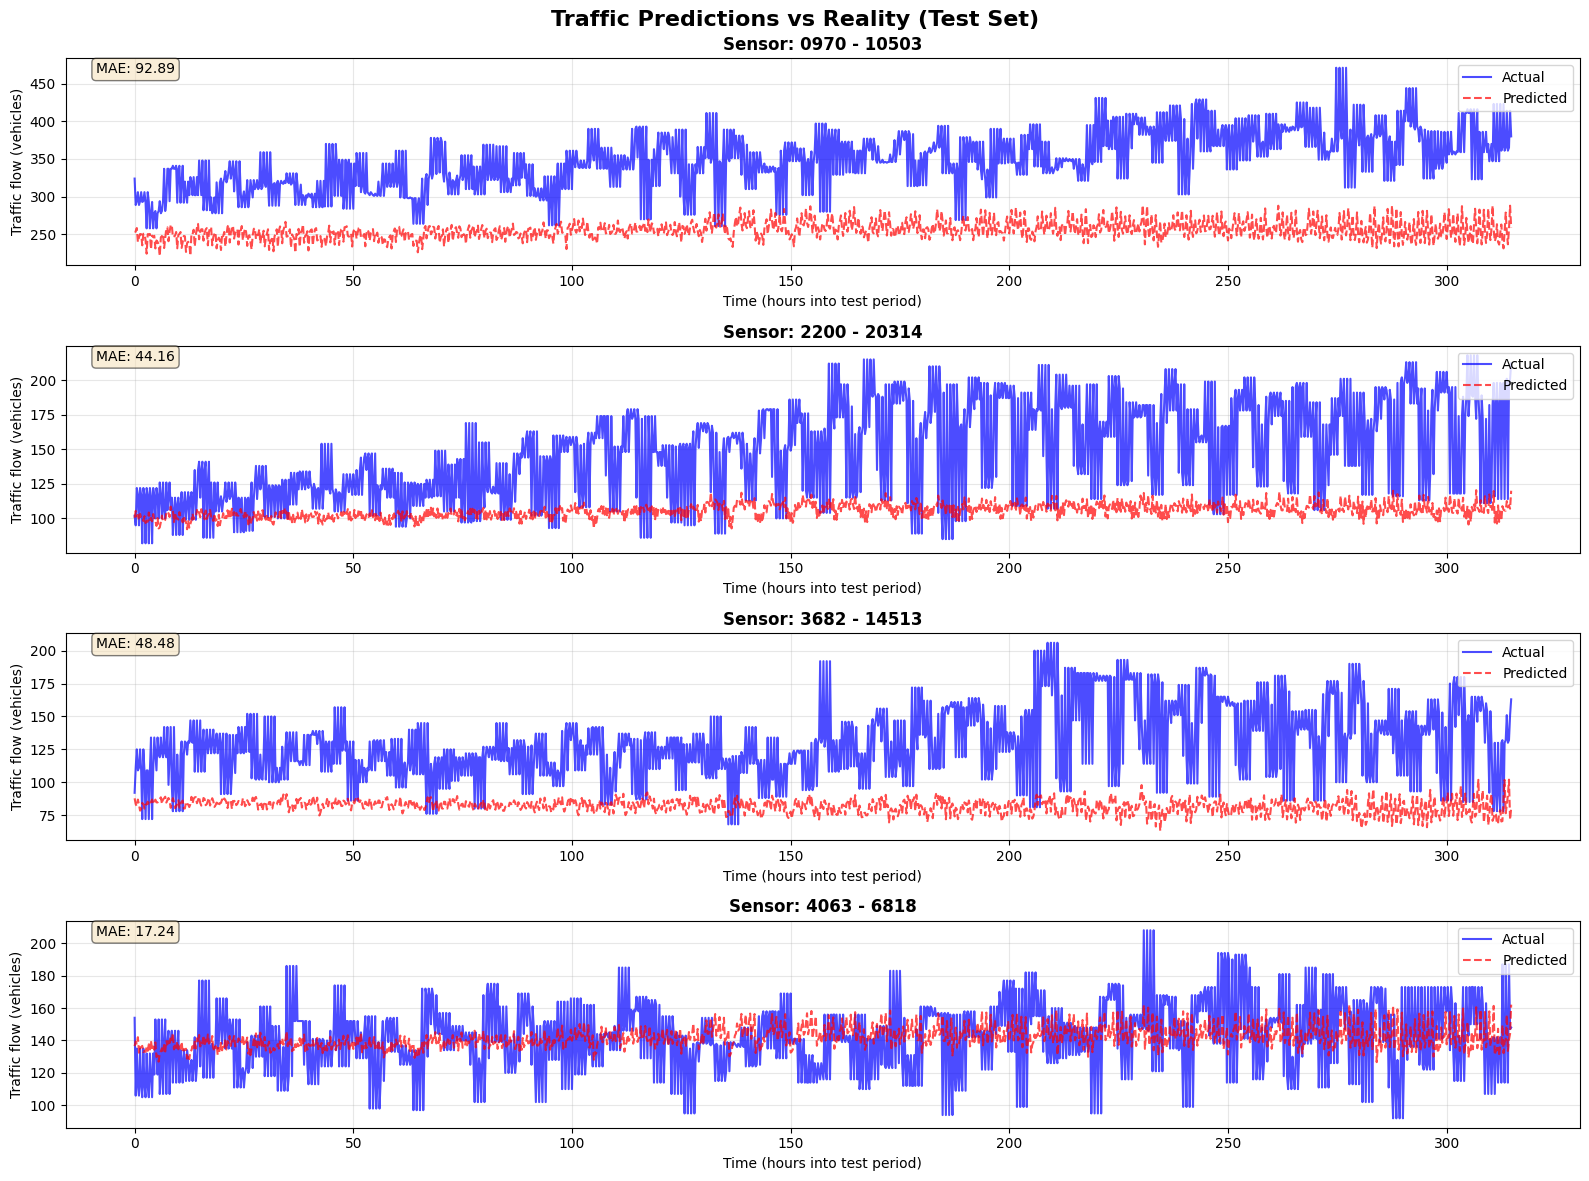

✓ Saved: predictions_vs_reality_timeseries.png


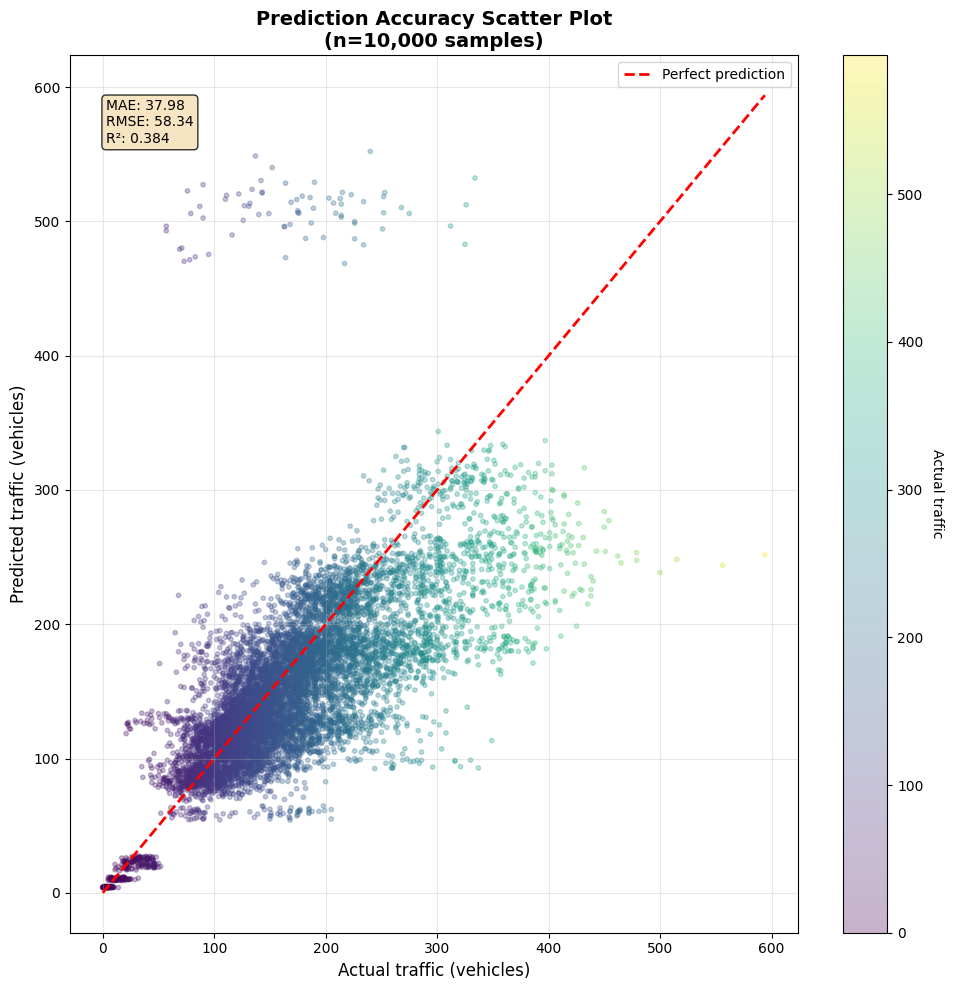

✓ Saved: predictions_scatter.png


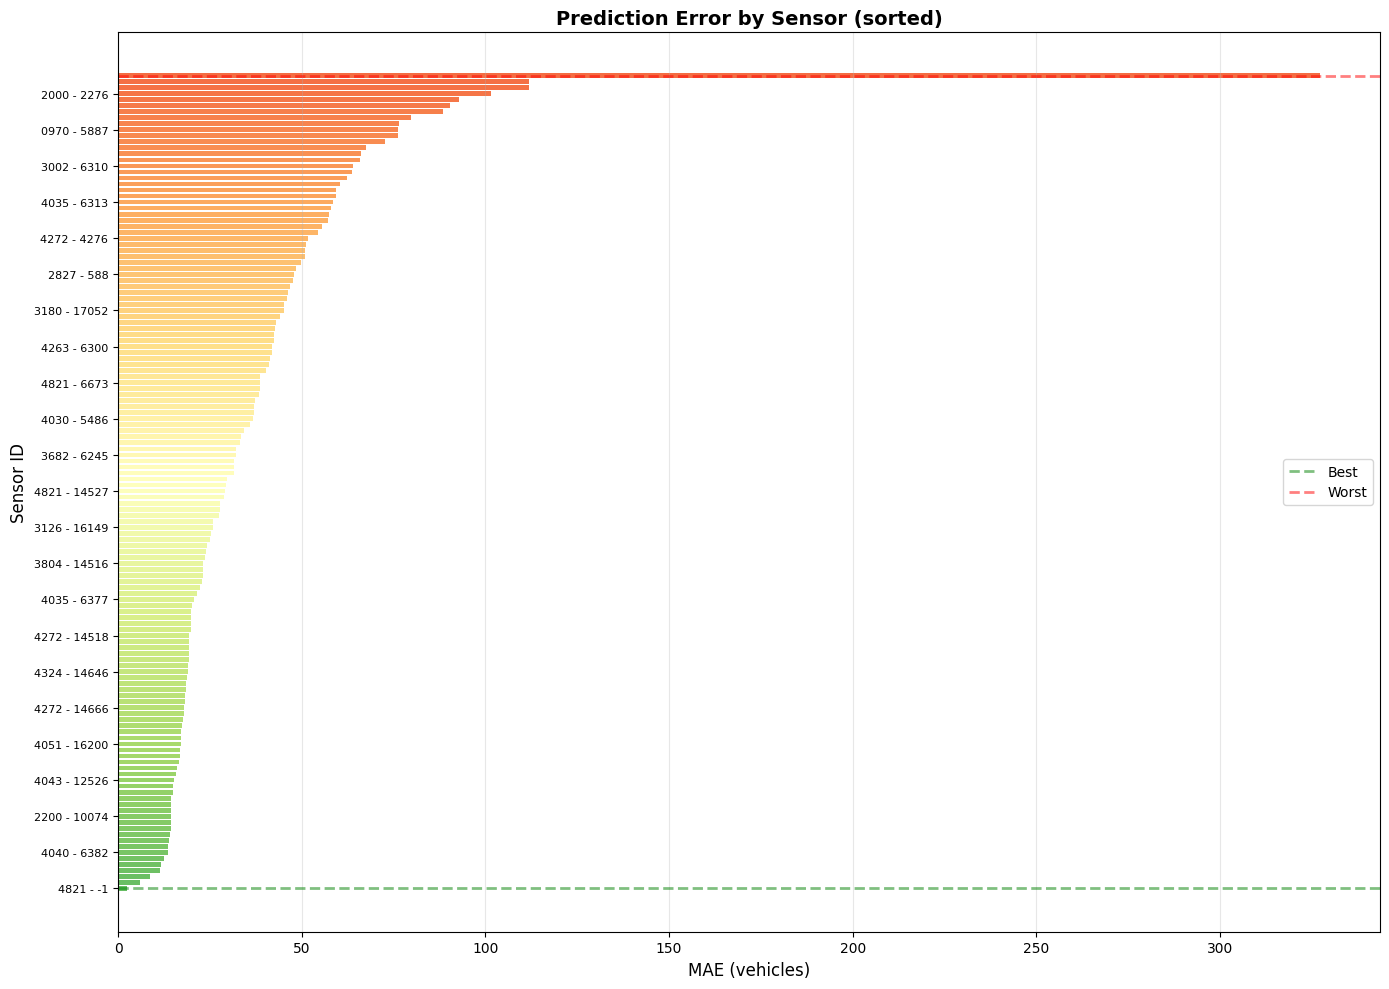

✓ Saved: error_by_sensor.png

🎯 Best sensor: 4821 - -1 (MAE: 2.55)
😟 Worst sensor: 3685 - 10504 (MAE: 327.19)


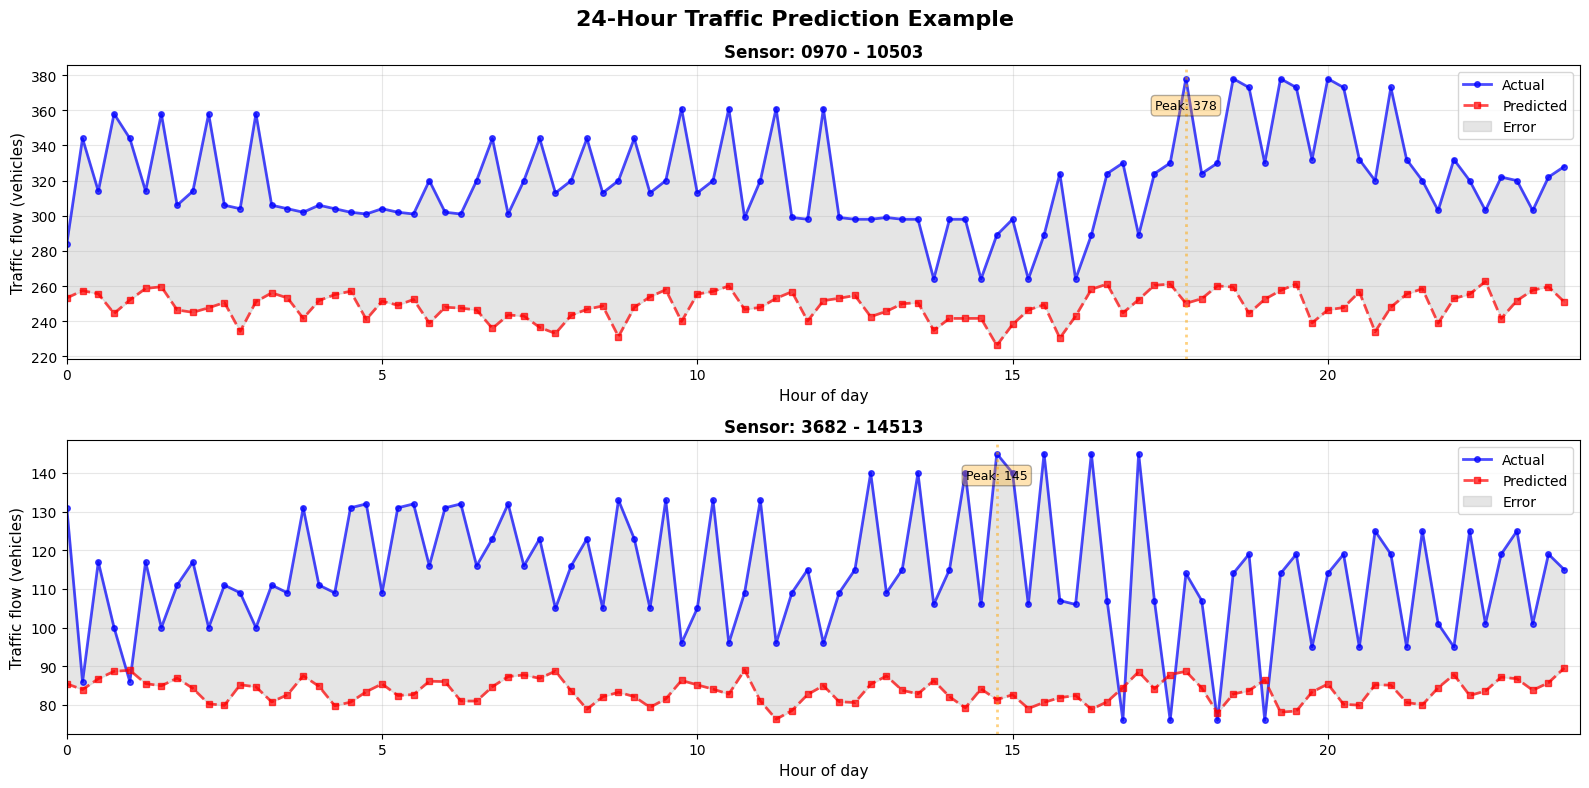

✓ Saved: 24hour_prediction.png


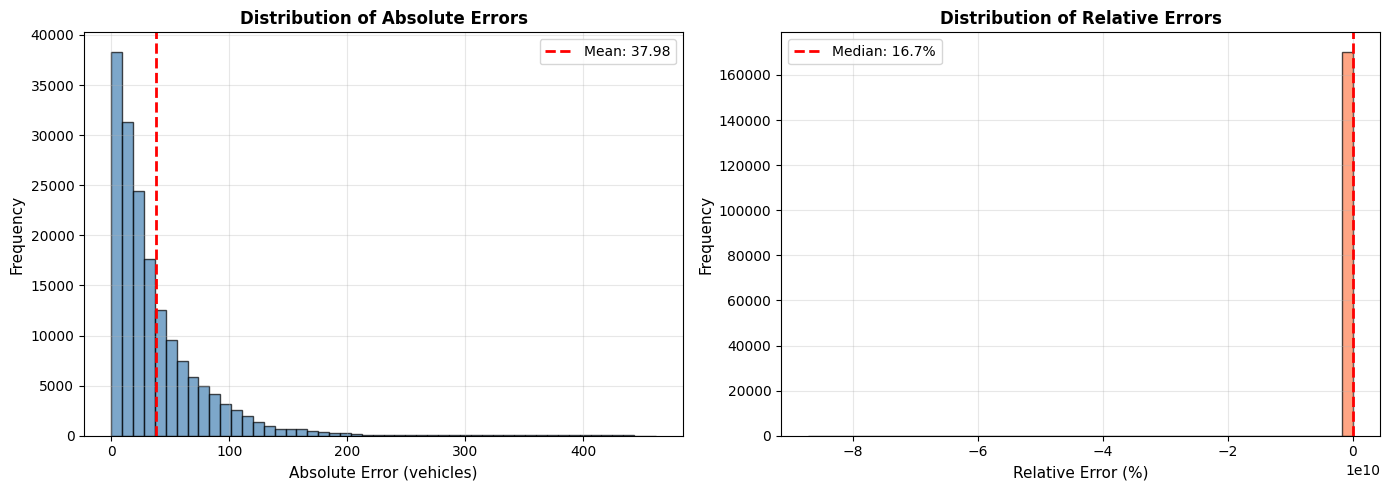

✓ Saved: error_distribution.png

✅ All visualizations complete!

📈 Summary Statistics:
   Overall MAE:  37.98 vehicles
   Overall RMSE: 58.34 vehicles
   Median Relative Error: 16.7%
   90th Percentile Error: 87.50 vehicles


In [34]:
# ====================================
# STEP 10: VISUALIZE PREDICTIONS VS REALITY
# ====================================
import matplotlib.pyplot as plt
import numpy as np

print("\n📊 Generating visualizations...")

# -----------------------------
# 1. TIME SERIES: Multiple Sensors
# -----------------------------
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle('Traffic Predictions vs Reality (Test Set)', fontsize=16, fontweight='bold')

# Select 4 interesting sensors to visualize
sensors_to_plot = [0, 10, 50, 100]
sensor_names = [df_locations['id'].iloc[i] for i in sensors_to_plot]

for idx, sensor_idx in enumerate(sensors_to_plot):
    ax = axes[idx]
    
    # Flatten predictions across all test windows for this sensor
    y_true_sensor = Y_true[:, :, sensor_idx].flatten()
    y_pred_sensor = Y_pred[:, :, sensor_idx].flatten()
    
    # Create time axis (each point is 15 minutes)
    time_steps = np.arange(len(y_true_sensor)) * 0.25  # Convert to hours
    
    # Plot
    ax.plot(time_steps, y_true_sensor, 'b-', label='Actual', alpha=0.7, linewidth=1.5)
    ax.plot(time_steps, y_pred_sensor, 'r--', label='Predicted', alpha=0.7, linewidth=1.5)
    
    ax.set_title(f'Sensor: {sensor_names[idx]}', fontweight='bold')
    ax.set_xlabel('Time (hours into test period)')
    ax.set_ylabel('Traffic flow (vehicles)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Calculate MAE for this sensor
    sensor_mae = np.mean(np.abs(y_true_sensor - y_pred_sensor))
    ax.text(0.02, 0.98, f'MAE: {sensor_mae:.2f}', 
            transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('predictions_vs_reality_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: predictions_vs_reality_timeseries.png")


# -----------------------------
# 2. SCATTER PLOT: Overall Accuracy
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))

# Sample points to avoid overcrowding (use all if dataset is small)
sample_size = min(10000, Y_true.size)
indices = np.random.choice(Y_true.size, sample_size, replace=False)

y_true_flat = Y_true.flatten()[indices]
y_pred_flat = Y_pred.flatten()[indices]

# Scatter plot
scatter = ax.scatter(y_true_flat, y_pred_flat, alpha=0.3, s=10, c=y_true_flat, cmap='viridis')
ax.plot([y_true_flat.min(), y_true_flat.max()], 
        [y_true_flat.min(), y_true_flat.max()], 
        'r--', lw=2, label='Perfect prediction')

ax.set_xlabel('Actual traffic (vehicles)', fontsize=12)
ax.set_ylabel('Predicted traffic (vehicles)', fontsize=12)
ax.set_title(f'Prediction Accuracy Scatter Plot\n(n={sample_size:,} samples)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Actual traffic', rotation=270, labelpad=15)

# Add statistics box
stats_text = f'MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nR²: {1 - np.sum((y_true_flat - y_pred_flat)**2) / np.sum((y_true_flat - np.mean(y_true_flat))**2):.3f}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('predictions_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: predictions_scatter.png")


# -----------------------------
# 3. ERROR HEATMAP: By Sensor
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 10))

# Calculate MAE per sensor
mae_per_sensor = np.array([
    np.mean(np.abs(Y_true[:, :, i] - Y_pred[:, :, i])) 
    for i in range(NUM_SENSORS)
])

# Sort sensors by error (best to worst)
sorted_indices = np.argsort(mae_per_sensor)
sorted_mae = mae_per_sensor[sorted_indices]
sorted_names = [df_locations['id'].iloc[i] for i in sorted_indices]

# Create horizontal bar chart with color gradient
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, NUM_SENSORS))
bars = ax.barh(np.arange(NUM_SENSORS), sorted_mae, color=colors)

# Add sensor names (show every Nth to avoid clutter)
step = max(1, NUM_SENSORS // 20)  # Show ~20 labels
ax.set_yticks(np.arange(0, NUM_SENSORS, step))
ax.set_yticklabels([sorted_names[i] for i in range(0, NUM_SENSORS, step)], fontsize=8)

ax.set_xlabel('MAE (vehicles)', fontsize=12)
ax.set_ylabel('Sensor ID', fontsize=12)
ax.set_title('Prediction Error by Sensor (sorted)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Highlight best and worst
ax.axhline(y=0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Best')
ax.axhline(y=NUM_SENSORS-1, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Worst')
ax.legend()

plt.tight_layout()
plt.savefig('error_by_sensor.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: error_by_sensor.png")

print(f"\n🎯 Best sensor: {sorted_names[0]} (MAE: {sorted_mae[0]:.2f})")
print(f"😟 Worst sensor: {sorted_names[-1]} (MAE: {sorted_mae[-1]:.2f})")


# -----------------------------
# 4. DETAILED VIEW: Single Day
# -----------------------------
# Show a complete 24-hour period
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('24-Hour Traffic Prediction Example', fontsize=16, fontweight='bold')

# Pick two contrasting sensors
example_sensors = [0, 50]
day_start_window = 50  # Start from window 50
hours_per_window = HORIZON * 0.25  # Each window predicts 1 hour
windows_for_24h = int(24 / hours_per_window)  # How many windows for 24 hours

for idx, sensor_idx in enumerate(example_sensors):
    ax = axes[idx]
    
    # Extract one day worth of predictions
    y_true_day = Y_true[day_start_window:day_start_window+windows_for_24h, :, sensor_idx].flatten()
    y_pred_day = Y_pred[day_start_window:day_start_window+windows_for_24h, :, sensor_idx].flatten()
    
    # Time axis in hours
    hours = np.arange(len(y_true_day)) * 0.25
    
    # Plot with markers
    ax.plot(hours, y_true_day, 'bo-', label='Actual', markersize=4, linewidth=2, alpha=0.7)
    ax.plot(hours, y_pred_day, 'rs--', label='Predicted', markersize=4, linewidth=2, alpha=0.7)
    
    # Shade error regions
    ax.fill_between(hours, y_true_day, y_pred_day, alpha=0.2, color='gray', label='Error')
    
    sensor_name = df_locations['id'].iloc[sensor_idx]
    ax.set_title(f'Sensor: {sensor_name}', fontweight='bold')
    ax.set_xlabel('Hour of day', fontsize=11)
    ax.set_ylabel('Traffic flow (vehicles)', fontsize=11)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 24])
    
    # Mark peak hours
    peak_idx = np.argmax(y_true_day)
    ax.axvline(x=hours[peak_idx], color='orange', linestyle=':', linewidth=2, alpha=0.5)
    ax.text(hours[peak_idx], ax.get_ylim()[1]*0.95, f'Peak: {y_true_day[peak_idx]:.0f}',
            ha='center', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))

plt.tight_layout()
plt.savefig('24hour_prediction.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 24hour_prediction.png")


# -----------------------------
# 5. ERROR DISTRIBUTION
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute errors
errors = np.abs(Y_true.flatten() - Y_pred.flatten())
axes[0].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=mae, color='red', linestyle='--', linewidth=2, label=f'Mean: {mae:.2f}')
axes[0].set_xlabel('Absolute Error (vehicles)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Absolute Errors', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Relative errors (percentage)
relative_errors = 100 * np.abs(Y_true.flatten() - Y_pred.flatten()) / (Y_true.flatten() + 1e-9)
relative_errors = relative_errors[relative_errors < 200]  # Filter outliers
axes[1].hist(relative_errors, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(x=np.median(relative_errors), color='red', linestyle='--', 
                linewidth=2, label=f'Median: {np.median(relative_errors):.1f}%')
axes[1].set_xlabel('Relative Error (%)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Relative Errors', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: error_distribution.png")


print("\n✅ All visualizations complete!")
print(f"\n📈 Summary Statistics:")
print(f"   Overall MAE:  {mae:.2f} vehicles")
print(f"   Overall RMSE: {rmse:.2f} vehicles")
print(f"   Median Relative Error: {np.median(relative_errors):.1f}%")
print(f"   90th Percentile Error: {np.percentile(errors, 90):.2f} vehicles")


🔍 DIAGNOSTIC ANALYSIS


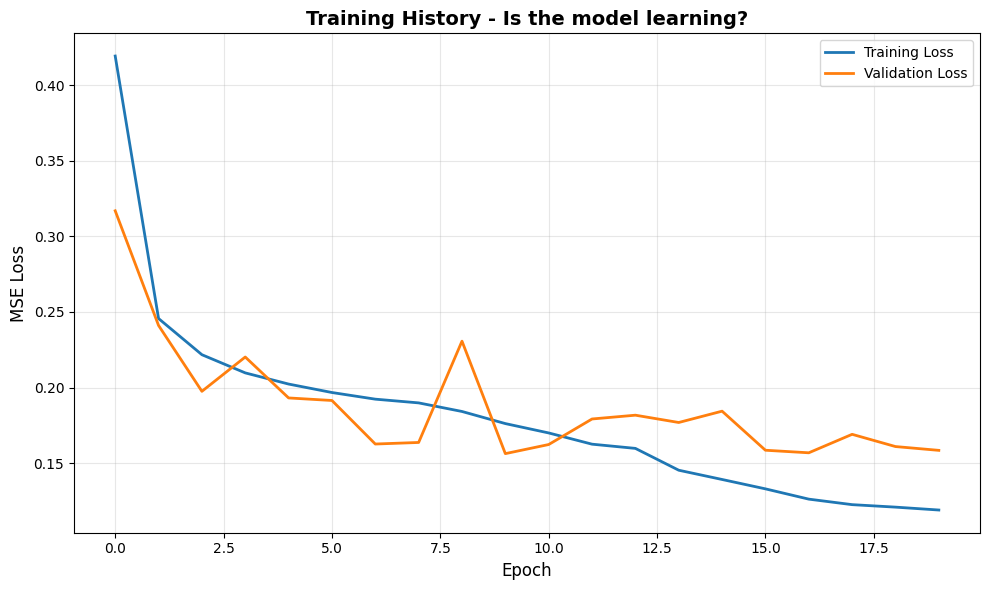

✓ Saved: training_loss.png

📉 Final Training Loss: 0.1189
📉 Final Validation Loss: 0.1584

📊 BASELINE COMPARISON (Persistence Model):
   Baseline MAE:  31.33 vehicles
   Baseline RMSE: 45.34 vehicles
   Your Model MAE:  37.98 vehicles
   Your Model RMSE: 58.34 vehicles
   ❌ Model is WORSE than baseline by 21.2%
   🚨 This suggests the model isn't learning useful patterns!

📈 DATA STATISTICS:
   Training data range: [0.0, 695.0]
   Training data mean: 104.3
   Training data std: 91.9
   Test predictions range: [3.5, 566.5]
   Test ground truth range: [-0.0, 616.0]
   Prediction variance: 3904.49
   Ground truth variance: 5332.89


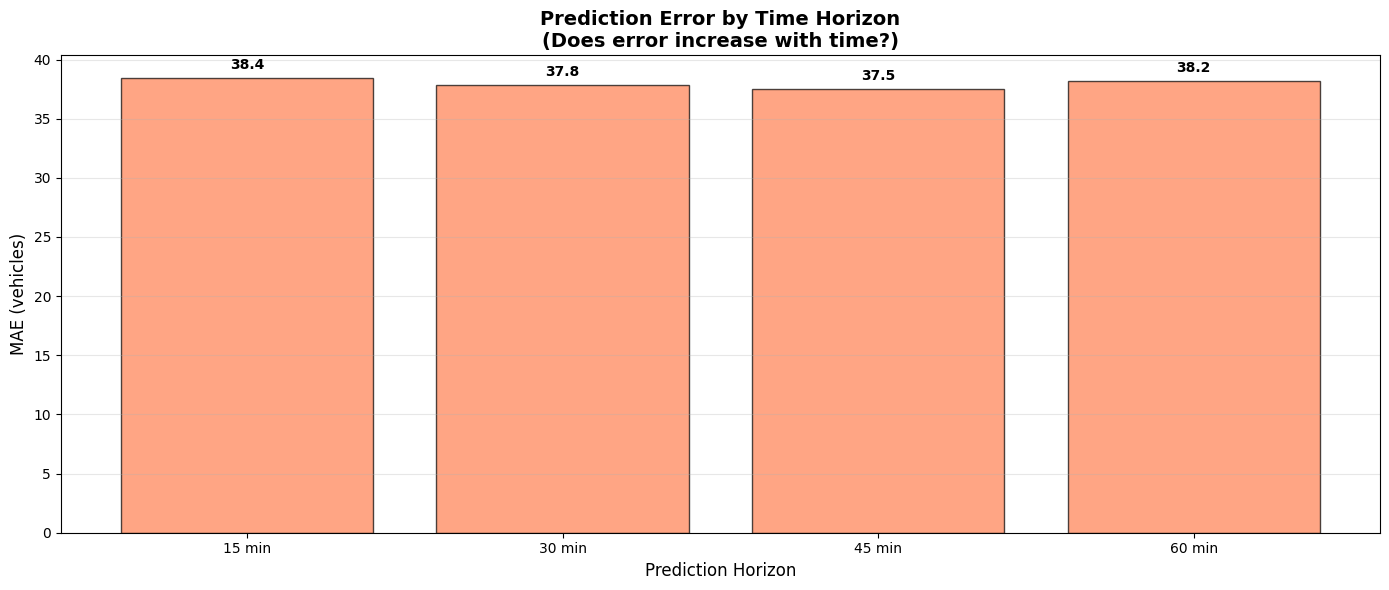


✓ Saved: error_by_horizon.png

🔴 WORST PREDICTIONS:
   1. 3685 - 10504: MAE=327.2 (Mean Traffic=261.5, Relative Error=125.1%)
   2. 2827 - 2578: MAE=111.9 (Mean Traffic=78.9, Relative Error=141.8%)
   3. 2820 - 16542: MAE=111.8 (Mean Traffic=145.8, Relative Error=76.7%)
   4. 2000 - 2276: MAE=101.5 (Mean Traffic=142.5, Relative Error=71.2%)
   5. 0970 - 10503: MAE=92.9 (Mean Traffic=178.3, Relative Error=52.1%)

💡 SUGGESTIONS TO IMPROVE:
   1. ❌ Model is worse than baseline - try:
      - Increase LSTM units (128 → 256)
      - Add more LSTM layers
      - Increase training epochs
      - Try different learning rate
   3. ⚠️  High absolute error - try:
      - Increase lookback window (3 hrs → 6 hrs)
      - Add more features (time of day, day of week)
      - Remove low-traffic sensors



In [35]:
# ====================================
# STEP 11: DIAGNOSTIC ANALYSIS
# ====================================
import matplotlib.pyplot as plt
import numpy as np

print("\n🔍 DIAGNOSTIC ANALYSIS")
print("="*50)

# -----------------------------
# 1. Check Training Loss Curve
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title('Training History - Is the model learning?', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=300)
plt.show()
print("✓ Saved: training_loss.png")

# Check if model is learning
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
print(f"\n📉 Final Training Loss: {final_train_loss:.4f}")
print(f"📉 Final Validation Loss: {final_val_loss:.4f}")

if final_val_loss > 0.5:
    print("⚠️  WARNING: High validation loss - model may not be learning well!")

# -----------------------------
# 2. Baseline Comparison
# -----------------------------
# Simple baseline: predict using previous value (persistence model)
Y_baseline = np.zeros_like(Y_true)
for i in range(len(Y_test)):
    # Use the last value from input window as prediction
    Y_baseline[i] = data[:, val_split + i + LOOKBACK - 1].reshape(1, -1)

baseline_mae = np.mean(np.abs(Y_true.flatten() - Y_baseline.flatten()))
baseline_rmse = np.sqrt(np.mean((Y_true.flatten() - Y_baseline.flatten()) ** 2))

print(f"\n📊 BASELINE COMPARISON (Persistence Model):")
print(f"   Baseline MAE:  {baseline_mae:.2f} vehicles")
print(f"   Baseline RMSE: {baseline_rmse:.2f} vehicles")
print(f"   Your Model MAE:  {mae:.2f} vehicles")
print(f"   Your Model RMSE: {rmse:.2f} vehicles")

improvement = ((baseline_mae - mae) / baseline_mae) * 100
if improvement > 0:
    print(f"   ✅ Improvement over baseline: {improvement:.1f}%")
else:
    print(f"   ❌ Model is WORSE than baseline by {abs(improvement):.1f}%")
    print("   🚨 This suggests the model isn't learning useful patterns!")

# -----------------------------
# 3. Data Statistics
# -----------------------------
print(f"\n📈 DATA STATISTICS:")
print(f"   Training data range: [{data.min():.1f}, {data.max():.1f}]")
print(f"   Training data mean: {data.mean():.1f}")
print(f"   Training data std: {data.std():.1f}")
print(f"   Test predictions range: [{Y_pred.min():.1f}, {Y_pred.max():.1f}]")
print(f"   Test ground truth range: [{Y_true.min():.1f}, {Y_true.max():.1f}]")

# Check if predictions are too flat
pred_variance = np.var(Y_pred)
true_variance = np.var(Y_true)
print(f"   Prediction variance: {pred_variance:.2f}")
print(f"   Ground truth variance: {true_variance:.2f}")

if pred_variance < true_variance * 0.1:
    print("   ⚠️  WARNING: Predictions are too flat! Model may be regressing to mean.")

# -----------------------------
# 4. Error by Time of Day
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate MAE for each time step in horizon
errors_by_horizon = np.array([
    np.mean(np.abs(Y_true[:, h, :] - Y_pred[:, h, :]))
    for h in range(HORIZON)
])

time_labels = [f'{h*15} min' for h in range(1, HORIZON+1)]
ax.bar(range(HORIZON), errors_by_horizon, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel('Prediction Horizon', fontsize=12)
ax.set_ylabel('MAE (vehicles)', fontsize=12)
ax.set_title('Prediction Error by Time Horizon\n(Does error increase with time?)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(range(HORIZON))
ax.set_xticklabels(time_labels)
ax.grid(True, alpha=0.3, axis='y')

for i, v in enumerate(errors_by_horizon):
    ax.text(i, v + max(errors_by_horizon)*0.02, f'{v:.1f}', 
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('error_by_horizon.png', dpi=300)
plt.show()
print("\n✓ Saved: error_by_horizon.png")

# -----------------------------
# 5. Worst Case Examples
# -----------------------------
print(f"\n🔴 WORST PREDICTIONS:")

# Find sensors with highest error
worst_sensors = sorted_indices[-5:][::-1]
for rank, sensor_idx in enumerate(worst_sensors, 1):
    sensor_mae = mae_per_sensor[sensor_idx]
    sensor_name = df_locations['id'].iloc[sensor_idx]
    mean_traffic = np.mean(data[sensor_idx])
    relative_error = (sensor_mae / mean_traffic) * 100 if mean_traffic > 0 else 0
    
    print(f"   {rank}. {sensor_name}: MAE={sensor_mae:.1f} "
          f"(Mean Traffic={mean_traffic:.1f}, Relative Error={relative_error:.1f}%)")

# -----------------------------
# 6. Suggestions
# -----------------------------
print(f"\n💡 SUGGESTIONS TO IMPROVE:")

if improvement < 0:
    print("   1. ❌ Model is worse than baseline - try:")
    print("      - Increase LSTM units (128 → 256)")
    print("      - Add more LSTM layers")
    print("      - Increase training epochs")
    print("      - Try different learning rate")

if pred_variance < true_variance * 0.1:
    print("   2. ⚠️  Predictions are too flat - try:")
    print("      - Reduce dropout (0.2 → 0.1)")
    print("      - Check if data normalization is correct")
    print("      - Use MAE loss instead of MSE")

if mae > data.mean() * 0.3:
    print("   3. ⚠️  High absolute error - try:")
    print("      - Increase lookback window (3 hrs → 6 hrs)")
    print("      - Add more features (time of day, day of week)")
    print("      - Remove low-traffic sensors")

if errors_by_horizon[-1] > errors_by_horizon[0] * 2:
    print("   4. ⚠️  Error grows with time - try:")
    print("      - Multi-step training (predict 1 step at a time)")
    print("      - Reduce horizon (4 steps → 2 steps)")
    print("      - Use sequence-to-sequence architecture")

print(f"\n{'='*50}")